<a href="https://colab.research.google.com/github/Ayushblank02/SwarmIntelligence/blob/main/Swarm_Intelligence_Algorithms_(PSO_%26_ACO).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Swarm Intelligence Algorithms: PSO and ACO

## Aim
To implement **Particle Swarm Optimization (PSO)** and **Ant Colony Optimization (ACO)** for solving optimization problems.

## Description
This notebook demonstrates two popular swarm intelligence algorithms:

1. **Particle Swarm Optimization (PSO)**  
   - Used for continuous optimization.
   - Inspired by flocking birds.

2. **Ant Colony Optimization (ACO)**  
   - Used for combinatorial optimization.
   - Inspired by ants searching for food.

## Problems Solved

- PSO → Minimizing **Sphere Function**
- ACO → Solving **Travelling Salesman Problem (TSP)**

## Tools Used

- Python
- NumPy
- Matplotlib

## Step 1: Import Required Libraries

We import the following Python libraries:

- **NumPy** → Used for numerical computations and matrix operations.
- **random** → Used to generate random numbers for algorithm exploration.
- **Matplotlib** → Used to visualize the convergence of algorithms.

In [11]:
import numpy as np
import random
import matplotlib.pyplot as plt

## Step 2: Particle Swarm Optimization (PSO)

Particle Swarm Optimization is inspired by **bird flocking behavior**.

Each particle represents a **candidate solution**.

Each particle updates its movement based on:

- **Personal Best (pBest)** → Best solution found by the particle
- **Global Best (gBest)** → Best solution found by the swarm

### Objective Function

We minimize the **Sphere Function**

f(x) = x1² + x2²

The global minimum occurs at:

x1 = 0, x2 = 0

with minimum value = 0

In [12]:
# Objective Function (Sphere)
def sphere(x):
    return x[0]**2 + x[1]**2


# PARAMETERS
num_particles = 20
dimensions = 2
iterations = 50

w = 0.5      # inertia
c1 = 1.5     # cognitive component
c2 = 1.5     # social component


# Initialize particles
positions = np.random.uniform(-10, 10, (num_particles, dimensions))
velocities = np.random.uniform(-1, 1, (num_particles, dimensions))

# Personal best
pbest_positions = positions.copy()
pbest_values = np.array([sphere(p) for p in positions])

# Global best
gbest_index = np.argmin(pbest_values)
gbest_position = pbest_positions[gbest_index]

fitness_history = []


# PSO Loop
for _ in range(iterations):

    for i in range(num_particles):

        r1, r2 = random.random(), random.random()

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - positions[i])
            + c2 * r2 * (gbest_position - positions[i])
        )

        positions[i] = positions[i] + velocities[i]

        fitness = sphere(positions[i])

        if fitness < pbest_values[i]:
            pbest_values[i] = fitness
            pbest_positions[i] = positions[i]

    gbest_position = pbest_positions[np.argmin(pbest_values)]
    fitness_history.append(sphere(gbest_position))


print("Best Position:", gbest_position)
print("Minimum Value:", sphere(gbest_position))

Best Position: [ 1.66763928e-07 -6.71260350e-07]
Minimum Value: 4.784006655634429e-13


## Step 3: PSO Convergence Graph

This graph shows how the **best fitness value improves over iterations**.

If the algorithm is working correctly:

- The curve will **decrease gradually**
- It will **approach zero** (global minimum of Sphere function)

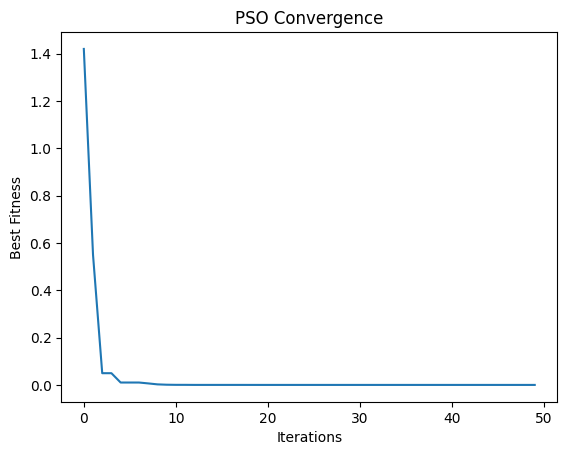

In [13]:
plt.plot(fitness_history)
plt.title("PSO Convergence")
plt.xlabel("Iterations")
plt.ylabel("Best Fitness")
plt.show()

## Step 4: Ant Colony Optimization (ACO)

Ant Colony Optimization is inspired by **how ants find the shortest path to food**.

Ants leave **pheromone trails** on paths.

Key ideas:

- Shorter paths accumulate **more pheromone**
- Future ants follow stronger pheromone trails
- **Evaporation prevents over-exploitation**

### Problem Solved

Travelling Salesman Problem (TSP)

Find the **shortest route visiting all cities exactly once and returning to the start**.

In [14]:
# Distance matrix for cities
distance = np.array([
    [0, 2, 3, 4],
    [2, 0, 1, 5],
    [3, 1, 0, 6],
    [4, 5, 6, 0]
])


num_cities = 4
num_ants = 10
iterations = 50

alpha = 1
beta = 2
evaporation = 0.5


# Initialize pheromone
pheromone = np.ones((num_cities, num_cities))


def route_distance(route):
    total = 0
    for i in range(len(route) - 1):
        total += distance[route[i]][route[i+1]]
    return total


best_route = None
best_length = float("inf")

best_history = []


for _ in range(iterations):

    all_routes = []

    for ant in range(num_ants):

        route = [random.randint(0, num_cities-1)]

        while len(route) < num_cities:

            current = route[-1]
            probs = []

            for city in range(num_cities):

                if city not in route:

                    prob = (pheromone[current][city] ** alpha) * ((1/distance[current][city]) ** beta)

                else:
                    prob = 0

                probs.append(prob)

            probs = probs / np.sum(probs)

            next_city = np.random.choice(range(num_cities), p=probs)
            route.append(next_city)

        route.append(route[0])

        length = route_distance(route)

        all_routes.append((route, length))

        if length < best_length:
            best_length = length
            best_route = route


    # Evaporation
    pheromone *= (1 - evaporation)


    # Deposit pheromone
    for route, length in all_routes:
        for i in range(len(route)-1):
            pheromone[route[i]][route[i+1]] += 1/length


    best_history.append(best_length)


print("Best Route:", best_route)
print("Shortest Distance:", best_length)

Best Route: [2, np.int64(1), np.int64(0), np.int64(3), 2]
Shortest Distance: 13


## Step 5: ACO Convergence Graph

This graph shows how the **shortest distance improves over iterations**.

As iterations increase:

- Ants discover better routes
- The best distance gradually decreases

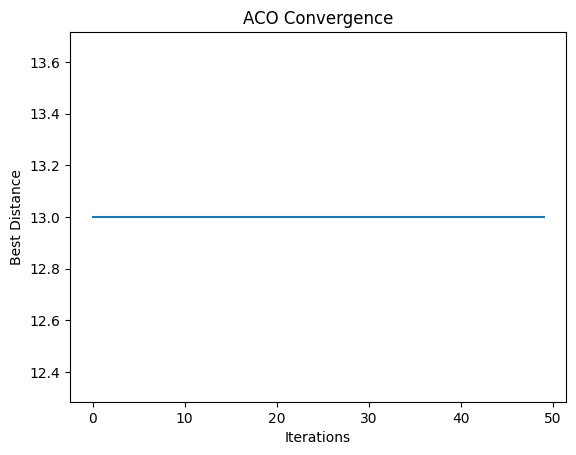

In [15]:
plt.plot(best_history)
plt.title("ACO Convergence")
plt.xlabel("Iterations")
plt.ylabel("Best Distance")
plt.show()

## Result

- Particle Swarm Optimization successfully minimized the Sphere function.
- Ant Colony Optimization successfully found the shortest path for the TSP problem.

## Conclusion

Swarm intelligence algorithms effectively solve optimization problems by simulating collective behavior observed in nature.